# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора



**Вариант 2: задания 1 и 2 на наборе данных MNIST**



Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scripts.data_utils import load_CIFAR10


%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 

sklearn.datasets import load_digits

digits = load_digits()

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()

X_train, X_test, y_train, y_test = train_test_split(
    digits.images,
    digits.target,
    test_size=0.2,
    random_state=42,
    stratify=digits.target,
)

print("Training data shape: ", X_train.shape)
print("Training labels shape: ", y_train.shape)
print("Test data shape: ", X_test.shape)
print("Test labels shape: ", y_test.shape)

Training data shape:  (1437, 8, 8)
Training labels shape:  (1437,)
Test data shape:  (360, 8, 8)
Test labels shape:  (360,)


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.

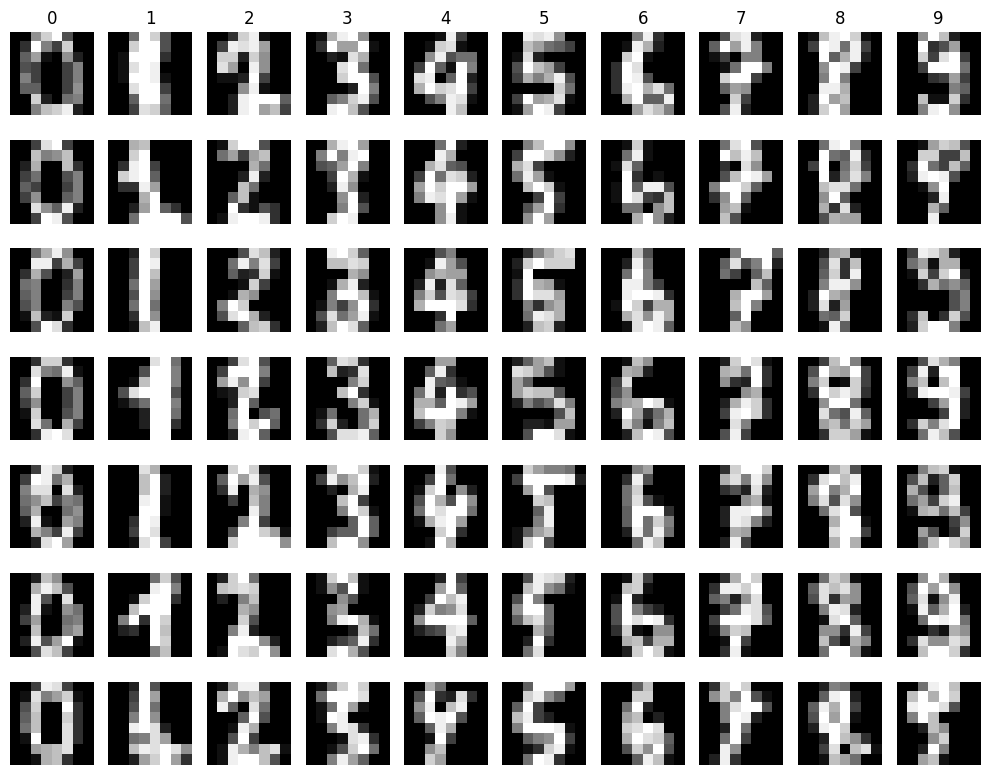

In [3]:
classes = np.unique(y_train)
samples_per_class = 7

for y_cls in classes:
    idxs = np.flatnonzero(y_train == y_cls)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)

    for i, idx in enumerate(idxs):
        plt_idx = i * len(classes) + y_cls + 1
        plt.subplot(samples_per_class, len(classes), plt_idx)

        plt.imshow(X_train[idx], cmap="gray")
        plt.axis("off")

        if i == 0:
            plt.title(str(y_cls))


plt.tight_layout()
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [4]:
X = digits.images
y = digits.target

X_flattened = X.reshape((len(X), -1))

X_train, X_test, y_train, y_test = train_test_split(
    X_flattened,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("=== Reshape results ===")
print(f"Original data form (X): {X.shape}")
print(f"Form after vectorization (X_flattened): {X_flattened.shape}")
print("-" * 33)
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

=== Reshape results ===
Original data form (X): (1797, 8, 8)
Form after vectorization (X_flattened): (1797, 64)
---------------------------------
X_train: (1437, 64)
X_test:  (360, 64)
y_train: (1437,)
y_test:  (360,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [5]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [6]:
y_test_pred = classifier.predict(X_test, k=5, num_loops=0)

1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


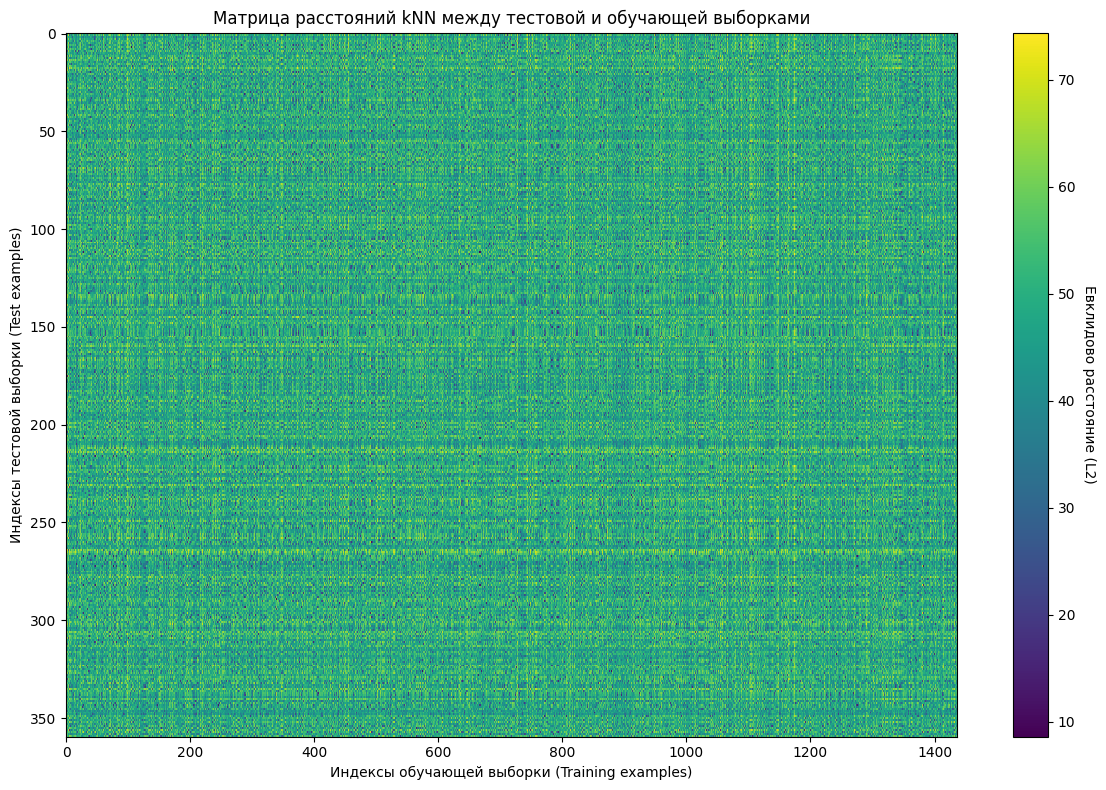

Размерность матрицы расстояний: (360, 1437)
Минимальное расстояние: 8.60
Максимальное расстояние: 74.40
Среднее расстояние: 48.44


In [7]:
dists = classifier.compute_distances_no_loops(X_test)

plt.figure(figsize=(12, 8))


im = plt.imshow(dists, interpolation="none", aspect="auto", cmap="viridis")

cbar = plt.colorbar(im)
cbar.set_label("Евклидово расстояние (L2)", rotation=270, labelpad=15)

plt.xlabel("Индексы обучающей выборки (Training examples)")
plt.ylabel("Индексы тестовой выборки (Test examples)")
plt.title("Матрица расстояний kNN между тестовой и обучающей выборками")

plt.tight_layout()
plt.show()

print(f"Размерность матрицы расстояний: {dists.shape}")
print(f"Минимальное расстояние: {np.min(dists):.2f}")
print(f"Максимальное расстояние: {np.max(dists):.2f}")
print(f"Среднее расстояние: {np.mean(dists):.2f}")


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [8]:
num_correct = np.sum(y_test_pred == y_test)
num_test = y_test.shape[0]
accuracy_numpy = np.mean(y_test_pred == y_test)

print(f"Total test images: {num_test}")
print(f"Correctly classified: {num_correct}")
print(f"Percentage of correct answers: {accuracy_numpy:.4f}")

Total test images: 360
Correctly classified: 354
Percentage of correct answers: 0.9833


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

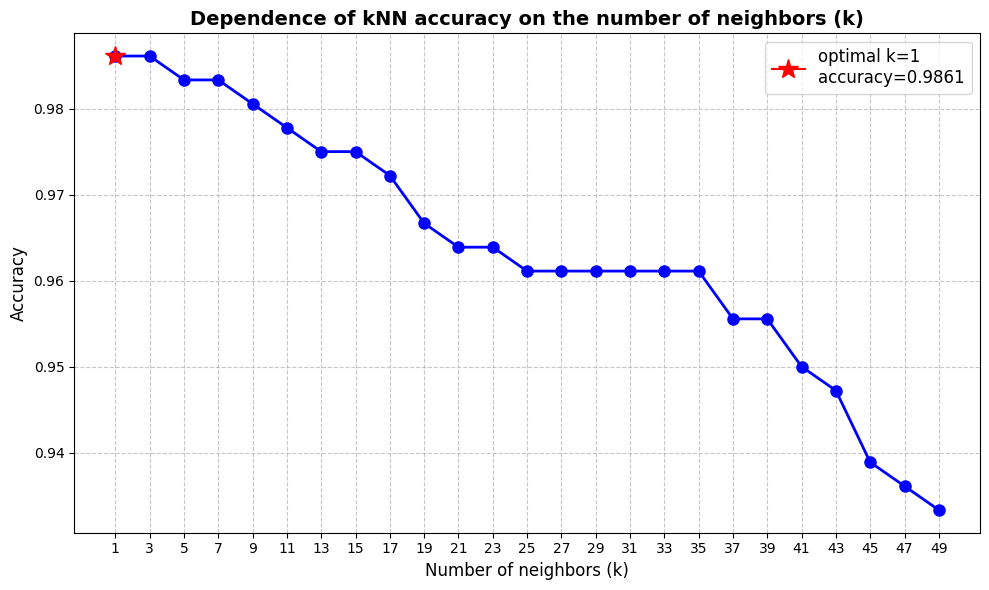

In [9]:
k_choices = np.arange(1, 50, 2)
k_accuracies = []
dists = classifier.compute_distances_no_loops(X_test)

for k in k_choices:
    y_test_pred = classifier.predict_labels(dists, k=k)

    accuracy = np.mean(y_test_pred == y_test)
    k_accuracies.append(accuracy)


best_idx = np.argmax(k_accuracies)
best_k = k_choices[best_idx]
best_acc = k_accuracies[best_idx]


plt.figure(figsize=(10, 6))

plt.plot(
    k_choices,
    k_accuracies,
    marker="o",
    linestyle="-",
    color="b",
    linewidth=2,
    markersize=8,
)

plt.plot(
    best_k,
    best_acc,
    marker="*",
    color="r",
    markersize=15,
    label=f"optimal k={best_k}\naccuracy={best_acc:.4f}",
)


plt.title(
    "Dependence of kNN accuracy on the number of neighbors (k)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Number of neighbors (k)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(k_choices)
plt.legend(loc="best", fontsize=12)

plt.tight_layout()
plt.show()

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [10]:
num_folds = 5
k_choices = np.arange(1, 50, 2)
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)
cv_results = {}

for k in k_choices:
    cv_results[k] = []
    for i in range(num_folds):
        X_val_fold = X_train_folds[i]
        y_val_fold = y_train_folds[i]
        X_train_fold = np.concatenate(X_train_folds[:i] + X_train_folds[i + 1 :])
        y_train_fold = np.concatenate(y_train_folds[:i] + y_train_folds[i + 1 :])
        classifier = KNearestNeighbor()
        classifier.train(X_train_fold, y_train_fold)
        y_val_pred = classifier.predict(X_val_fold, k=k, num_loops=0)
        accuracy = np.mean(y_val_pred == y_val_fold)
        cv_results[k].append(accuracy)

for k in sorted(cv_results):
    for accuracy in cv_results[k]:
        print(f"k = {k}, accuracy = {accuracy:.4f}")

best_k = None
best_accuracy = -1

for k, acc_list in cv_results.items():
    avg_acc = np.mean(acc_list)
    if avg_acc >= best_accuracy:
        best_accuracy = avg_acc
        best_k = k

print(f"best k: {best_k}")

k = 1, accuracy = 1.0000
k = 1, accuracy = 0.9965
k = 1, accuracy = 0.9965
k = 1, accuracy = 0.9826
k = 1, accuracy = 0.9721
k = 3, accuracy = 0.9931
k = 3, accuracy = 0.9931
k = 3, accuracy = 0.9930
k = 3, accuracy = 0.9861
k = 3, accuracy = 0.9686
k = 5, accuracy = 0.9931
k = 5, accuracy = 0.9896
k = 5, accuracy = 0.9930
k = 5, accuracy = 0.9861
k = 5, accuracy = 0.9617
k = 7, accuracy = 0.9965
k = 7, accuracy = 0.9826
k = 7, accuracy = 0.9930
k = 7, accuracy = 0.9791
k = 7, accuracy = 0.9512
k = 9, accuracy = 0.9931
k = 9, accuracy = 0.9861
k = 9, accuracy = 0.9930
k = 9, accuracy = 0.9652
k = 9, accuracy = 0.9547
k = 11, accuracy = 0.9931
k = 11, accuracy = 0.9826
k = 11, accuracy = 0.9930
k = 11, accuracy = 0.9617
k = 11, accuracy = 0.9512
k = 13, accuracy = 0.9861
k = 13, accuracy = 0.9826
k = 13, accuracy = 0.9930
k = 13, accuracy = 0.9547
k = 13, accuracy = 0.9512
k = 15, accuracy = 0.9826
k = 15, accuracy = 0.9826
k = 15, accuracy = 0.9930
k = 15, accuracy = 0.9547
k = 15, acc


1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.


In [11]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
predictions = classifier.predict(X_test, k=best_k)

final_accuracy = np.mean(predictions == y_test)
total_errors = np.sum(predictions != y_test)
total_test_samples = len(y_test)

print(f"Accuracy: {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print(f"Number of errors: {total_errors} of {total_test_samples} images")

Accuracy: 0.9861 (98.61%)
Number of errors: 5 of 360 images


1.11 Сделайте выводы по результатам 1 части задания.

1. **Проблема Inference (предсказания):** kNN мгновенно "обучается" (просто запоминает данные), но работает недопустимо медленно на этапе предсказания, что делает его непригодным для использования в проде на больших данных.
2. **Сила векторизации:** Использование циклов `for` для расчета дистанций убивает производительность. Переход к матричным вычислениям NumPy (через формулу квадрата разности) ускоряет код на несколько порядков.
3. **Критичность гиперпараметра $k$:** Качество алгоритма зависит только от $k$. При $k=1$ модель переобучается на шуме, при больших $k$ — недообучается. Кросс-валидация обязательна для поиска баланса.
4. **Ограниченность пиксельных метрик:** L2-расстояние (Евклидова метрика) "в лоб" по сырым пикселям плохо отражает суть картинки — малейший сдвиг объекта сильно искажает расстояние. Поэтому kNN справляется с простыми датасетами (digits 8x8), но проваливается на сложных.

## 2.  Классификация данных методом опорных векторов (SVM)

2.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [12]:
X = digits.images
y = digits.target

X_flattened = X.reshape((len(X), -1))

X_train, X_temp, y_train, y_temp = train_test_split(
    X_flattened,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp,
)

print("=== Reshape results ===")
print(f"Original data form (X): {X.shape}")
print(f"Form after vectorization (X_flattened): {X_flattened.shape}")
print("-" * 33)
print(f"X_train: {X_train.shape}")
print(f"X_val:  {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:  {y_val.shape}")
print(f"y_test:  {y_test.shape}")

=== Reshape results ===
Original data form (X): (1797, 8, 8)
Form after vectorization (X_flattened): (1797, 64)
---------------------------------
X_train: (1437, 64)
X_val:  (180, 64)
X_test:  (180, 64)
y_train: (1437,)
y_val:  (180,)
y_test:  (180,)


2.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

2.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву дынных и заполните ее 1.

[0.00000000e+00 3.04801670e-01 5.16353514e+00 1.18107168e+01
 1.19004871e+01 5.89561587e+00 1.38970077e+00 1.37787056e-01
 5.56715379e-03 1.97007655e+00]


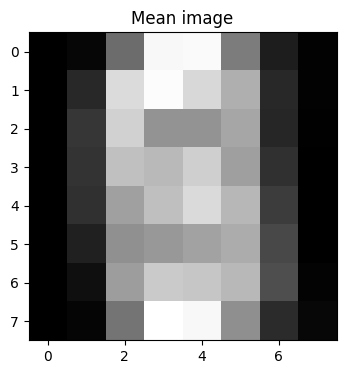

(1437, 65) (180, 65) (180, 65)


In [13]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])
plt.figure(figsize=(4, 4))
plt.title("Mean image")
plt.imshow(mean_image.reshape((8, 8)), cmap="gray")
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image


X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

2.4 Реализуйте loss-функции в scripts/classifiers/linear_svm.py



In [14]:
from scripts.classifiers.linear_svm import svm_loss_naive, svm_loss_vectorized
import time


W = np.random.randn(65, 10) * 0.0001

loss, grad = svm_loss_naive(W, X_train, y_train, 0.000005)
print("loss: %f" % (loss,))

loss, grad = svm_loss_vectorized(W, X_train, y_train, 0.000005)
print("loss: %f" % (loss,))

loss: 8.992814
loss: 8.992814



2.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [15]:
loss, grad = svm_loss_naive(W, X_train, y_train, 0.0)

from scripts.gradient_check import grad_check_sparse

f = lambda w: svm_loss_naive(w, X_train, y_train, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_naive(W, X_train, y_train, 5e1)
f = lambda w: svm_loss_naive(w, X_train, y_train, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: 2.098613 analytic: 2.098613, relative error: 2.015975e-10
numerical: 2.570533 analytic: 2.570533, relative error: 2.377864e-11
numerical: 1.318775 analytic: 1.318775, relative error: 3.044973e-10
numerical: -3.509801 analytic: -3.509801, relative error: 2.996918e-11
numerical: -0.243040 analytic: -0.243040, relative error: 1.652124e-09
numerical: -1.258755 analytic: -1.258755, relative error: 1.819199e-10
numerical: -4.349833 analytic: -4.349833, relative error: 8.881309e-12
numerical: 0.016262 analytic: 0.016262, relative error: 2.303989e-08
numerical: -0.603825 analytic: -0.603825, relative error: 5.662375e-10
numerical: 8.113056 analytic: 8.113056, relative error: 3.853231e-11
numerical: 5.541626 analytic: 5.541626, relative error: 6.708347e-11
numerical: 0.011659 analytic: 0.011659, relative error: 7.652481e-10
numerical: 6.742384 analytic: 6.742384, relative error: 6.580287e-11
numerical: 0.192131 analytic: 0.192131, relative error: 4.426461e-09
numerical: 5.541626 anal

In [16]:
loss, grad = svm_loss_vectorized(W, X_train, y_train, 0.0)

from scripts.gradient_check import grad_check_sparse

f = lambda w: svm_loss_vectorized(w, X_train, y_train, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)


loss, grad = svm_loss_vectorized(W, X_train, y_train, 5e1)
f = lambda w: svm_loss_vectorized(w, X_train, y_train, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -0.016006 analytic: -0.016006, relative error: 1.870588e-09
numerical: -1.388791 analytic: -1.388791, relative error: 2.765743e-11
numerical: -3.430439 analytic: -3.430439, relative error: 9.791108e-12
numerical: -1.189451 analytic: -1.189451, relative error: 4.719402e-11
numerical: -4.043586 analytic: -4.043586, relative error: 8.583968e-13
numerical: 1.749048 analytic: 1.749048, relative error: 1.189061e-11
numerical: 1.768981 analytic: 1.768981, relative error: 1.334291e-12
numerical: -1.950630 analytic: -1.950630, relative error: 3.153154e-12
numerical: -0.009047 analytic: -0.009047, relative error: 2.611446e-09
numerical: -1.421954 analytic: -1.421954, relative error: 2.372715e-11
numerical: -0.773038 analytic: -0.773038, relative error: 3.138353e-11
numerical: 0.200031 analytic: 0.200031, relative error: 1.655318e-10
numerical: -0.261314 analytic: -0.261314, relative error: 1.095121e-10
numerical: 1.854104 analytic: 1.854104, relative error: 1.349199e-12
numerical: -0.

2.6 Сравните svm_loss_naive и svm_loss_vectorized реализации

In [17]:
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_train, y_train, 0.000005)
toc = time.time()
print("Naive loss and gradient: computed in %fs" % (toc - tic))

tic = time.time()
_, grad_vectorized = svm_loss_vectorized(W, X_train, y_train, 0.000005)
toc = time.time()
print("Vectorized loss and gradient: computed in %fs" % (toc - tic))

difference = np.linalg.norm(grad_naive - grad_vectorized, ord="fro")
print("difference: %f" % difference)

Naive loss and gradient: computed in 0.035299s
Vectorized loss and gradient: computed in 0.000411s
difference: 0.000000


2.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

In [18]:
from scripts.classifiers import LinearSVM

svm = LinearSVM()
tic = time.time()
loss_hist = svm.train(
    X_train, y_train, learning_rate=1e-7, reg=2.5e4, num_iters=1500, verbose=True
)
toc = time.time()
print("That took %fs" % (toc - tic))

iteration 0 / 1500: loss 23.218295
iteration 100 / 1500: loss 14.155907
iteration 200 / 1500: loss 10.862935
iteration 300 / 1500: loss 9.661629
iteration 400 / 1500: loss 9.206707
iteration 500 / 1500: loss 9.044142
iteration 600 / 1500: loss 8.986454
iteration 700 / 1500: loss 8.963492
iteration 800 / 1500: loss 8.954556
iteration 900 / 1500: loss 8.951562
iteration 1000 / 1500: loss 8.946728
iteration 1100 / 1500: loss 8.953482
iteration 1200 / 1500: loss 8.946159
iteration 1300 / 1500: loss 8.950891
iteration 1400 / 1500: loss 8.951620
That took 0.166973s


In [19]:
y_train_pred = svm.predict(X_train)
print("training accuracy: %f" % (np.mean(y_train == y_train_pred),))
y_val_pred = svm.predict(X_val)
print("validation accuracy: %f" % (np.mean(y_val == y_val_pred),))

training accuracy: 0.873347
validation accuracy: 0.866667


2.8 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [20]:
from itertools import product

learning_rates = np.logspace(-7, -2, num=6)
regularization_strengths = np.logspace(-2, 5, num=8)

results = {}

best_val = -1
best_svm = None
best_lr = None
best_reg = None

for lr, reg in product(learning_rates, regularization_strengths):
    svm = LinearSVM()
    loss_hist = svm.train(
        X_train,
        y_train,
        learning_rate=lr,
        reg=reg,
        num_iters=1500,
        verbose=False,
    )

    y_train_pred = svm.predict(X_train)
    train_acc = np.mean(y_train == y_train_pred)

    y_val_pred = svm.predict(X_val)
    val_acc = np.mean(y_val == y_val_pred)

    results[(lr, reg)] = (train_acc, val_acc)

    if val_acc > best_val:
        best_val = val_acc
        best_svm = svm
        best_lr = lr
        best_reg = reg


# for lr, reg in sorted(results):
#     train_accuracy, val_accuracy = results[(lr, reg)]
#     print(f"lr {lr} | reg {reg} => train acc: {train_accuracy:.4f} | val acc: {val_accuracy:.4f}")

print(f"LR grid: {learning_rates}")
print(f"reg grid: {regularization_strengths}")
print(f"\nBest val acc: {best_val:.4f}")
print(f"Best params: lr={best_lr:.2e}, reg={best_reg:.2e}")


y_test_pred = best_svm.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)

print(f"Best model test acc: {test_accuracy:.4f} ===")

c:\Users\ddima\Desktop\SSAU\labs\TofAI\DL_Course_SamU_2025\lab_1-2\scripts\classifiers\linear_svm.py:91: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
c:\Users\ddima\Desktop\SSAU\labs\TofAI\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\ddima\Desktop\SSAU\labs\TofAI\DL_Course_SamU_2025\lab_1-2\scripts\classifiers\linear_svm.py:91: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
c:\Users\ddima\Desktop\SSAU\labs\TofAI\DL_Course_SamU_2025\lab_1-2\scripts\classifiers\linear_svm.py:112: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W
c:\Users\ddima\Desktop\SSAU\labs\TofAI\DL_Course_SamU_2025\lab_1-2\scripts\classifiers\linear_svm.py:86: RuntimeWarning: invalid value encountered in dot
  scores = X.dot(W)
c:\Users\ddima\Desktop\SSAU\labs\TofAI\DL_Course_SamU_2025\lab_1-2\scripts\c

LR grid: [1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02]
reg grid: [1.e-02 1.e-01 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05]

Best val acc: 0.9778
Best params: lr=1.00e-03, reg=1.00e-02
Best model test acc: 0.9333 ===


2.9 Сделайте выводы по второй части задания
1. **Предобработка и Bias Trick:** Центрирование данных ускоряет сходимость, а добавление фиктивного признака (единицы) позволяет объединить матрицу весов ($W$) и вектор смещения ($b$), упростив математику.
2. **Сила векторизации:** Переход от наивных циклов `for` к матричным вычислениям NumPy ускоряет работу алгоритма на несколько порядков.
3. **Эффективность SGD:** Использование стохастического спуска на мини-батчах доказало свою состоятельность: модель обучается в разы быстрее без потери способности к обобщению.
4. **Критичность гиперпараметров:** Кросс-валидация наглядно продемонстрировала эффект «взрыва градиента» при завышенном `learning_rate`. Только точная настройка параметров позволила модели достичь уверенного базового качества (точность >90% на тесте).

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

In [21]:
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10])
plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((32, 32, 3)).astype("uint8"))
plt.show()


X_train -= mean_image
X_val -= mean_image
X_test -= mean_image


X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])


print(X_train.shape, X_val.shape, X_test.shape)

[ 0.00000000e+00  9.84289585e-17 -2.94205239e-16 -1.30043660e-15
 -1.97537803e-15 -1.55508483e-15 -9.09656638e-16 -9.99741541e-17
 -3.07602567e-17  5.78521225e-16]


ValueError: cannot reshape array of size 65 into shape (32,32,3)

<Figure size 400x400 with 0 Axes>

3.4 Реализуйте функции в classifiers/softmax.py




In [ ]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print("loss: %f" % loss)
print("sanity check: %f" % (-np.log(0.1)))

3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [ ]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse

f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [ ]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print("naive loss: %e computed in %fs" % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized

tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print("vectorized loss: %e computed in %fs" % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord="fro")
print("Loss difference: %f" % np.abs(loss_naive - loss_vectorized))
print("Gradient difference: %f" % grad_difference)

3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [ ]:
learning_rates = [1e-7, 5e-5]
regularization_strengths = [2.5e4, 5e4]

3.10 Сделайте выводы по третьей части задания